In [102]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

code pour lundi. manque landlocked dans le fichier matrix, et pq _x et _y ? fichier matrix à vérifier ou refaire, c'est la base de la suite du projet.

In [ ]:
df_main = pd.read_csv("/Users/romain/Desktop/Projets DS/ProjetStat/data_final/FINAL_GRAVITY_TRAINING_MATRIX.csv")
#print(gravity_data.head())
df_main.columns







Index(['iso3_o', 'iso3_d', 'year', 'migrantCount', 'distcap', 'contig',
       'comlang_off', 'col_dep_ever', 'pop_o', 'pop_15_64_pct_x',
       'pop_65_plus_pct_x', 'IMR_o', 'urban_o', 'LA_o', 'PSR_o', 'pop_d',
       'pop_15_64_pct_y', 'pop_65_plus_pct_y', 'IMR_d', 'urban_d', 'LA_d',
       'PSR_d', 'log_migrantCount', 'log_distcap', 'log_pop_o', 'log_pop_d',
       'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d', 'log_urban_o',
       'log_urban_d', 'log_LA_o', 'log_LA_d', 't_centered', 't_centered_sq'],
      dtype='object')

In [125]:
df_main.describe()

,year,migrantCount,distcap,contig,comlang_off,col_dep_ever,pop_o,pop_15_64_pct_x,pop_65_plus_pct_x,IMR_o,...,log_IMR_o,log_IMR_d,log_urban_o,log_urban_d,log_LA_o,log_LA_d,t_centered,t_centered_sq,landlocked_o,landlocked_d
count,105646.000000,1.056460e+05,105646.000000,105646.000000,105646.00000,105646.000000,1.056460e+05,105646.000000,105646.000000,105646.000000,...,105646.000000,105646.000000,105646.000000,105646.000000,105646.000000,105646.000000,105646.000000,105646.000000,104471.000000,104888.000000
mean,2000.088787,5.212587e+03,6974.511722,0.033565,0.18403,0.022831,5.144637e+07,62.200044,7.967482,31.449067,...,2.896101,2.859079,3.989679,4.015910,12.207817,12.197745,0.088787,49.793650,0.161337,0.164890
std,7.055936,4.314272e+04,4454.808329,0.180107,0.38751,0.149365,1.474113e+08,6.719394,5.226991,31.461213,...,1.107532,1.108733,0.489554,0.471210,2.361544,2.350501,7.055936,41.782257,0.367843,0.371083
min,1990.000000,1.000000e+00,59.617230,0.000000,0.00000,0.000000,6.275300e+04,45.776877,0.862465,1.700000,...,0.530628,0.530628,1.689358,1.689358,2.995732,2.995732,-10.000000,0.000000,0.000000,0.000000
25%,1995.000000,6.000000e+00,3283.508000,0.000000,0.00000,0.000000,4.133900e+06,56.703262,3.455495,6.800000,...,1.916923,1.871802,3.746771,3.779017,11.038110,11.038110,-5.000000,25.000000,0.000000,0.000000
50%,2000.000000,5.200000e+01,6403.348000,0.000000,0.00000,0.000000,1.057310e+07,64.400281,5.569668,17.700000,...,2.873565,2.815409,4.142500,4.170395,12.605419,12.597162,0.000000,25.000000,0.000000,0.000000
75%,2005.000000,6.570000e+02,9853.350000,0.000000,0.00000,0.000000,4.286928e+07,67.293320,12.536309,48.000000,...,3.871201,3.828641,4.352533,4.356247,13.694246,13.690004,5.000000,100.000000,0.000000,0.000000
max,2010.000000,3.817502e+06,19812.040000,1.000000,1.00000,1.000000,1.337705e+09,85.249494,23.098026,169.600000,...,5.133443,5.133443,4.605170,4.605170,16.611381,16.611381,10.000000,100.000000,1.000000,1.000000


In [104]:
df_main.head(50)

,iso3_o,iso3_d,year,migrantCount,distcap,contig,comlang_off,col_dep_ever,pop_o,pop_15_64_pct_x,...,log_PSR_o,log_PSR_d,log_IMR_o,log_IMR_d,log_urban_o,log_urban_d,log_LA_o,log_LA_d,t_centered,t_centered_sq
0,ABW,AGO,2005,1,9516.913,0.0,0.0,0.0,97635.0,70.108246,...,2.154336,2.940910,2.990720,4.547541,3.803881,4.025352,5.192957,14.036011,5,25
1,ABW,ARE,2005,1,12735.010,0.0,0.0,0.0,97635.0,70.108246,...,2.154336,3.817825,2.990720,2.041220,3.803881,4.409909,5.192957,11.170717,5,25
2,ABW,ARE,2010,1,12735.010,0.0,0.0,0.0,101838.0,69.709380,...,1.994177,4.051080,2.890372,1.945910,3.762571,4.431852,5.192957,11.170717,10,100
3,ABW,ARG,1995,1,5396.220,0.0,1.0,0.0,79805.0,67.362813,...,2.372545,1.894259,3.081910,3.039749,3.887054,4.479199,5.192957,14.822260,-5,25
4,ABW,ARG,2000,1,5396.220,0.0,1.0,0.0,90588.0,69.774621,...,2.331547,1.861960,3.058707,2.815409,3.844108,4.490231,5.192957,14.822260,0,0
5,ABW,ARG,2005,1,5396.220,0.0,1.0,0.0,97635.0,70.108246,...,2.154336,1.845557,2.990720,2.667228,3.803881,4.500154,5.192957,14.822260,5,25
6,ABW,ARG,2010,1,5396.220,0.0,1.0,0.0,101838.0,69.709380,...,1.994177,1.815582,2.890372,2.517696,3.762571,4.509199,5.192957,14.822260,10,100
7,ABW,ATG,1990,1,1024.995,0.0,0.0,0.0,62753.0,67.390157,...,2.234410,1.914993,3.104587,2.406945,3.918383,3.567446,5.192957,6.086775,-10,100
8,ABW,ATG,1995,2,1024.995,0.0,0.0,0.0,79805.0,67.362813,...,2.372545,2.053315,3.081910,2.533697,3.887054,3.525213,5.192957,6.086775,-5,25
9,ABW,ATG,2000,1,1024.995,0.0,0.0,0.0,90588.0,69.774621,...,2.331547,2.176426,3.058707,2.501436,3.844108,3.469697,5.192957,6.086775,0,0


In [105]:

df_geo= pd.read_excel("data/geo_cepii.xls")


# on prépare une version light de la table geo

geo_subset = df_geo[['iso3', 'landlocked']]

# ajouter landlocked_o
df_main = df_main.merge(geo_subset, left_on='iso3_o', right_on='iso3', how='left')

# La colonne s'ajoute sous le nom 'landlocked', on la renomme tout de suite
df_main = df_main.rename(columns={'landlocked': 'landlocked_o'})

# On supprime la colonne 'iso3' qui vient d'être ajoutée en doublon (celle de la table geo)
df_main = df_main.drop(columns=['iso3'])

#ajouter landlocked_d
df_main = df_main.merge(geo_subset, left_on='iso3_d', right_on='iso3', how='left')

# On renomme pour la destination
df_main = df_main.rename(columns={'landlocked': 'landlocked_d'})


df_main = df_main.drop(columns=['iso3'])

# Vérif
print(df_main[['iso3_o', 'landlocked_o', 'iso3_d', 'landlocked_d']].head())



  iso3_o  landlocked_o iso3_d  landlocked_d
0    ABW           0.0    AGO           0.0
1    ABW           0.0    ARE           0.0
2    ABW           0.0    ARE           0.0
3    ABW           0.0    ARG           0.0
4    ABW           0.0    ARG           0.0


In [106]:
df_main.head(50)
df_main.columns

Index(['iso3_o', 'iso3_d', 'year', 'migrantCount', 'distcap', 'contig',
       'comlang_off', 'col_dep_ever', 'pop_o', 'pop_15_64_pct_x',
       'pop_65_plus_pct_x', 'IMR_o', 'urban_o', 'LA_o', 'PSR_o', 'pop_d',
       'pop_15_64_pct_y', 'pop_65_plus_pct_y', 'IMR_d', 'urban_d', 'LA_d',
       'PSR_d', 'log_migrantCount', 'log_distcap', 'log_pop_o', 'log_pop_d',
       'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d', 'log_urban_o',
       'log_urban_d', 'log_LA_o', 'log_LA_d', 't_centered', 't_centered_sq',
       'landlocked_o', 'landlocked_d'],
      dtype='object')

In [107]:
import statsmodels.formula.api as smf


formula = """
log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq
"""


# cov_type='HC1' heteroskedasticity
results = smf.ols(formula, data=df_main.dropna()).fit(cov_type='HC1')


print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       log_migrantCount   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     5625.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:49:08   Log-Likelihood:            -2.2975e+05
No. Observations:              103713   AIC:                         4.595e+05
Df Residuals:                  103694   BIC:                         4.597e+05
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.8191      0.183     -9.955

In [108]:
df_cepii = pd.read_csv("reg_gravity_CEPII.csv")
df_cepii.head




/var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/ipykernel_31438/1235682718.py:1: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cepii = pd.read_csv("reg_gravity_CEPII.csv")


<bound method NDFrame.head of         iso_o  iso_d origIso destIso  year  migrantCount country_id_o  \
0         533      4     ABW     AFG  1990             0          ABW   
1         533      4     ABW     AFG  1995             0          ABW   
2         533      4     ABW     AFG  2000             0          ABW   
3         533      4     ABW     AFG  2005             0          ABW   
4         533      4     ABW     AFG  2010             0          ABW   
...       ...    ...     ...     ...   ...           ...          ...   
198995    716    894     ZWE     ZMB  1990          9676          ZWE   
198996    716    894     ZWE     ZMB  1995          4514          ZWE   
198997    716    894     ZWE     ZMB  2000         11438          ZWE   
198998    716    894     ZWE     ZMB  2005          9939          ZWE   
198999    716    894     ZWE     ZMB  2010          9495          ZWE   

       country_id_d iso3_o iso3_d  ...  tradeflow_comtrade_o  \
0               AFG    ABW   

In [109]:
df_main.columns

Index(['iso3_o', 'iso3_d', 'year', 'migrantCount', 'distcap', 'contig',
       'comlang_off', 'col_dep_ever', 'pop_o', 'pop_15_64_pct_x',
       'pop_65_plus_pct_x', 'IMR_o', 'urban_o', 'LA_o', 'PSR_o', 'pop_d',
       'pop_15_64_pct_y', 'pop_65_plus_pct_y', 'IMR_d', 'urban_d', 'LA_d',
       'PSR_d', 'log_migrantCount', 'log_distcap', 'log_pop_o', 'log_pop_d',
       'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d', 'log_urban_o',
       'log_urban_d', 'log_LA_o', 'log_LA_d', 't_centered', 't_centered_sq',
       'landlocked_o', 'landlocked_d'],
      dtype='object')

In [110]:
df_cepii.columns

df_cepii_subset = df_cepii[['iso_o']]

In [111]:
import pandas as pd
import numpy as np


# On prend iso3 + year comme clés
cols_eco = ['iso3_o', 'iso3_d', 'year', 'gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d']
df_eco = df_cepii[cols_eco].copy()



# fusionner valeurs courantes, t 
df_final = df_main.merge(df_eco, on=['iso3_o', 'iso3_d', 'year'], how='left')



# fusionner valeurs retardées, t-5

# On crée une colonne 'year_target' = année actuelle + 5 ans.
# L'année 2000 du fichier éco viendra s'accrocher à l'année 2005 du fichier principal.
df_eco_lag = df_eco.copy()
df_eco_lag['year_target'] = df_eco_lag['year'] + 5 

# On renomme les colonnes pour éviter les doublons (suffixe _lag)
cols_lag = {c: f'{c}_lag' for c in ['gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d']}
df_eco_lag = df_eco_lag.rename(columns=cols_lag)

# Fusion sur les clés + la clé temporelle décalée
df_final = df_final.merge(
    df_eco_lag[['iso3_o', 'iso3_d', 'year_target'] + list(cols_lag.values())],
    left_on=['iso3_o', 'iso3_d', 'year'],
    right_on=['iso3_o', 'iso3_d', 'year_target'],
    how='left'
)

# calcul des log (gérer les NaN)
vars_to_log = ['gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d', 
               'gdp_o_lag', 'gdp_d_lag', 'gdpcap_o_lag', 'gdpcap_d_lag']

for col in vars_to_log:
    # On remplace les valeurs <= 0 par NaN pour éviter l'erreur log(0)
    # Statsmodels supprimera automatiquement ces lignes lors de la régression
    df_final[col] = df_final[col].apply(lambda x: x if x > 0 else np.nan)
    df_final[f'log_{col}'] = np.log(df_final[col])


df_final = df_final.drop(columns=['year_target'])

print("Fusion terminée.")
print(df_final[['year', 'log_gdpcap_o', 'log_gdpcap_o_lag']].head())

Fusion terminée.
   year  log_gdpcap_o  log_gdpcap_o_lag
0  2005      3.148582          3.026261
1  2005      3.148582          3.026261
2  2010      3.190024          3.148582
3  1995      2.799778               NaN
4  2000      3.026261          2.799778


In [112]:
df_final.head(50)

,iso3_o,iso3_d,year,migrantCount,distcap,contig,comlang_off,col_dep_ever,pop_o,pop_15_64_pct_x,...,gdpcap_o_lag,gdpcap_d_lag,log_gdp_o,log_gdp_d,log_gdpcap_o,log_gdpcap_d,log_gdp_o_lag,log_gdp_d_lag,log_gdpcap_o_lag,log_gdpcap_d_lag
0,ABW,AGO,2005,1,9516.913,0.0,0.0,0.0,97635.0,70.108246,...,20.620,0.656,14.661810,17.156027,3.148582,0.534737,14.443294,16.027032,3.026261,-0.421594
1,ABW,ARE,2005,1,12735.010,0.0,0.0,0.0,97635.0,70.108246,...,20.620,34.476,14.661810,19.011889,3.148582,3.773542,14.443294,18.463140,3.026261,3.540263
2,ABW,ARE,2010,1,12735.010,0.0,0.0,0.0,101838.0,69.709380,...,23.303,43.534,14.718799,19.471675,3.190024,3.523002,14.661810,19.011889,3.148582,3.773542
3,ABW,ARG,1995,1,5396.220,0.0,1.0,0.0,79805.0,67.362813,...,NaN,4.333,14.093650,19.560336,2.799778,2.194220,NaN,18.766766,NaN,1.466260
4,ABW,ARG,2000,1,5396.220,0.0,1.0,0.0,90588.0,69.774621,...,16.441,8.973,14.443294,19.656945,3.026261,2.233128,14.093650,19.560336,2.799778,2.194220
5,ABW,ARG,2005,1,5396.220,0.0,1.0,0.0,97635.0,70.108246,...,20.620,9.329,14.661810,19.222268,3.148582,1.752325,14.443294,19.656945,3.026261,2.233128
6,ABW,ARG,2010,1,5396.220,0.0,1.0,0.0,101838.0,69.709380,...,23.303,5.768,14.718799,19.952598,3.190024,2.438863,14.661810,19.222268,3.148582,1.752325
7,ABW,ATG,1990,1,1024.995,0.0,0.0,0.0,62753.0,67.390157,...,NaN,NaN,NaN,12.877921,NaN,1.844510,NaN,NaN,NaN,NaN
8,ABW,ATG,1995,2,1024.995,0.0,0.0,0.0,79805.0,67.362813,...,NaN,6.325,14.093650,13.110666,2.799778,1.978239,NaN,12.877921,NaN,1.844510
9,ABW,ATG,2000,1,1024.995,0.0,0.0,0.0,90588.0,69.774621,...,16.441,7.230,14.443294,13.571957,3.026261,2.312040,14.093650,13.110666,2.799778,1.978239


In [113]:
# TEST GDP VS GDP PER CAPITA (intuition gdcpcap plus pertinent)


formula = """
log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq + log_gdp_o + log_gdp_d
"""

# cov_type='HC1' pour heteroskedascticity
results1 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')


print(results1.summary())

formula= """log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq + log_gdpcap_o + log_gdpcap_d"""
results2 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_migrantCount   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     5222.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:49:10   Log-Likelihood:            -1.4741e+05
No. Observations:               69554   AIC:                         2.949e+05
Df Residuals:                   69533   BIC:                         2.950e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.9794      0.208    -14.310

In [114]:
# TEST GDP RETARDÉ vs GDP COURANT 

formula = """
log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq + log_gdpcap_o_lag + log_gdpcap_d_lag
"""


# cov_type='HC1' pour heteroskedascticity
results1 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')


print(results1.summary())

formula= """log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq + log_gdpcap_o + log_gdpcap_d"""
results2 = smf.ols(formula, data=df_final.dropna()).fit(cov_type='HC1')
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_migrantCount   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     5215.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:49:11   Log-Likelihood:            -1.4734e+05
No. Observations:               69554   AIC:                         2.947e+05
Df Residuals:                   69533   BIC:                         2.949e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.0329      0.209  

In [118]:
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

#  Liste EXHAUSTIVE des variables du modèle

all_features = [
    'log_migrantCount', 
    'log_pop_o', 'log_pop_d', 'log_distcap', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d', 
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d', 
    'landlocked_o', 'landlocked_d', 
    'contig', 'comlang_off', 'col_dep_ever', 
    't_centered', 't_centered_sq'
]

#
# On ne garde que les lignes où TOUTES ces variables sont présentes
df_clean = df_final.dropna(subset=all_features).copy()

# Split Train/Test (Test = 2010)
train_df = df_clean[df_clean['year'] < 2010]
test_df  = df_clean[df_clean['year'] == 2010]

print(f"Lignes d'entraînement : {len(train_df)}")
print(f"Lignes de test (2010): {len(test_df)}")

# Train
formula = """
log_migrantCount ~ log_pop_o + log_pop_d + log_distcap 
+ log_PSR_o + log_PSR_d + log_IMR_o + log_IMR_d 
+ log_urban_o + log_urban_d + log_LA_o + log_LA_d 
+ landlocked_o + landlocked_d 
+ contig + comlang_off + col_dep_ever 
+ t_centered + t_centered_sq 

"""


model = smf.ols(formula, data=train_df).fit()

# Test
pred_log = model.predict(test_df)
    
y_pred_real = np.exp(pred_log)
y_true_real = np.exp(test_df['log_migrantCount'])

mse = mean_squared_error(y_true_real, y_pred_real)
mape = mean_absolute_percentage_error(y_true_real, y_pred_real)

print(f"\n--- PERFORMANCE OLS (Baseline 2010) ---")
print(f"MSE  : {mse:,.0f}")
print(f"MAPE : {mape:.2%}")


Lignes d'entraînement : 82963
Lignes de test (2010): 20750

--- PERFORMANCE OLS (Baseline 2010) ---
MSE  : 4,178,612,349
MAPE : 1463.77%


MSE ? MAPE ? comparaison avec ajout gdpcap et sans. 

Random forest: on attend une bosse migratoire, une cloche (pays pauvre: quand on commence à avoir les moyens on fuit, quand le pays devient asssez riche on reste)
L'effet de la distance est très mal jaugé par l'OLS: la distance joue t elle pareil en fonction de contig = 1 ou 0? on abesoin de dist*contig, que RF gère tout seul.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import PartialDependenceDisplay

#PREP DES DONNEES ET SPLIT TEMPOREL


# On reprend tes variables du "Modèle Lagged" (le plus performant économétriquement)
features = [
    'log_pop_o', 'log_pop_d', 'log_distcap', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d',
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d',
    'landlocked_o', 'landlocked_d', 
    'contig', 'comlang_off', 'col_dep_ever', 
    't_centered', 't_centered_sq', 
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]
target = 'log_migrantCount'

# Nettoyage strict (le RF ne gère pas les NaN)
df_ml = df_final.dropna(subset=features + [target]).copy()

# Split Temporel 
# Train : 1990-2005 ; Test : 2010 (Année de prédiction) (il manque l'année 2015)
train_df = df_ml[df_ml['year'] < 2010]
test_df  = df_ml[df_ml['year'] == 2010].copy() 

X_train, y_train = train_df[features], train_df[target]
X_test, y_test   = test_df[features], test_df[target]




# FEATURE IMPORTANCE RF 


# Choix des arguments :
# - n_estimators=100 : Suffisant pour stabiliser la variance sans exploser le temps de calcul (nbre de jurés)
# - max_depth=20 : Plus profond que projet elections car les flux migratoires 
#   ont une variance plus complexe. Il faut capter des interactions fines.

rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Calcul des R^2
r2_train = r2_score(y_train, rf.predict(X_train))
r2_test  = r2_score(y_test, rf.predict(X_test))

print(f"R^2 Random Forest (Entraînement 1990-2005) : {r2_train:.4f}")
print(f"R^2 Random Forest (Prédiction 2010)       : {r2_test:.4f}")

# Hiérarchie des variables (feature importance)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables ")
print(importances.head(10))




R^2 Random Forest (Entraînement 1990-2005) : 0.9778
R^2 Random Forest (Prédiction 2010)       : 0.8010

Importance des variables 
log_pop_o           0.177082
log_distcap         0.161586
log_pop_d           0.157749
log_gdpcap_d_lag    0.100145
log_gdpcap_o_lag    0.069036
contig              0.040304
log_LA_d            0.035027
log_IMR_d           0.034333
log_PSR_d           0.034297
log_LA_o            0.033638
dtype: float64


In [120]:
# Erreurs MSE et MAPE

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Prédiction sur le Test (en Log)
y_pred_log = rf.predict(X_test)

#  Retour à l'échelle réelle (Exponentielle)
# On veut comparer des humains, pas des logs d'humains
y_pred_real = np.exp(y_pred_log)
y_true_real = np.exp(y_test)

# calcul des erreurs 
mse_rf = mean_squared_error(y_true_real, y_pred_real) #somme des ecarts au carré
mape_rf = mean_absolute_percentage_error(y_true_real, y_pred_real) # somme des écarts relatifs

print(f"\n PERFORMANCE PRÉDICTIVE (Test 2010) ")
print(f"MSE (Random Forest)  : {mse_rf:,.0f}")
print(f"MAPE (Random Forest) : {mape_rf:.2%}")


 PERFORMANCE PRÉDICTIVE (Test 2010) 
MSE (Random Forest)  : 796,974,241
MAPE (Random Forest) : 396.44%


Min/Max de la variable :
min   -2.733368
max    3.973626
Name: log_gdpcap_o_lag, dtype: float64


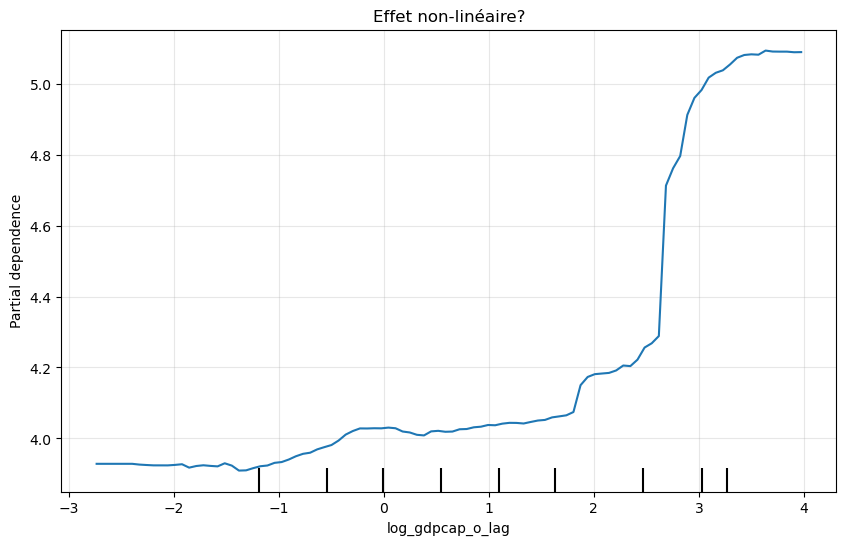

In [121]:
# PARTIAL DEPENDENCE PLOT (pour gdpcap)


import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Vérif de l'étendue réelle des données
print("Min/Max de la variable :")
print(X_train['log_gdpcap_o_lag'].describe()[['min', 'max']])

fig, ax = plt.subplots(figsize=(10, 6))


PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    ['log_gdpcap_o_lag'], 
    kind="average", 
    percentiles=(0, 1),  
    ax=ax
)

plt.title("Effet non-linéaire?")
plt.grid(True, alpha=0.3)
plt.show()

Log = -3 : 50$ par habitant. (Extrême pauvreté ou erreur de donnée).
Log = 2.5 : 12,100$ par habitant. (point de bascule).
Log = 3.0 : 20 000$ par habitant. (Entrée dans le club des pays occidentaux, c'est le seuil attendu)
Log = 4.4 : 80 000$ par habitant. (max dans le monde, qatar suisse etc)



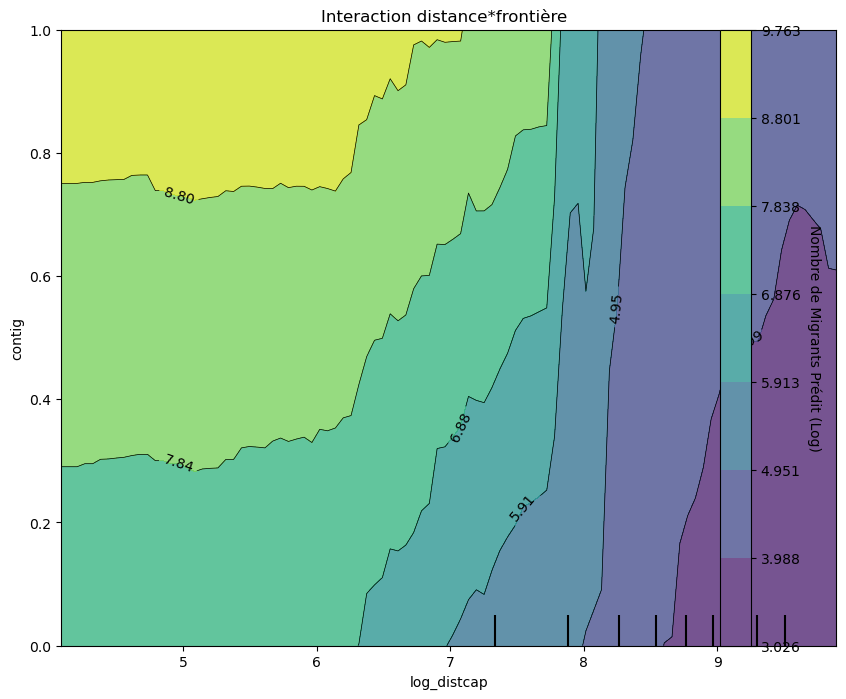

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# PDP 2D

features_inter = [('log_distcap', 'contig')] 
# ------------------

fig, ax = plt.subplots(figsize=(10, 8))

graph= PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    percentiles=(0, 1),   # Gamme complète
    n_cols=1,             
    ax=ax
)
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Nombre de Migrants Prédit (Log)', rotation=270, labelpad=15)
plt.title("Interaction distance*frontière  ")

plt.show()

montrer d'abord le graphe suivant pour la compréhension, qui lui est linéaire dans la progression en couleur vis à vis de l'axe X.


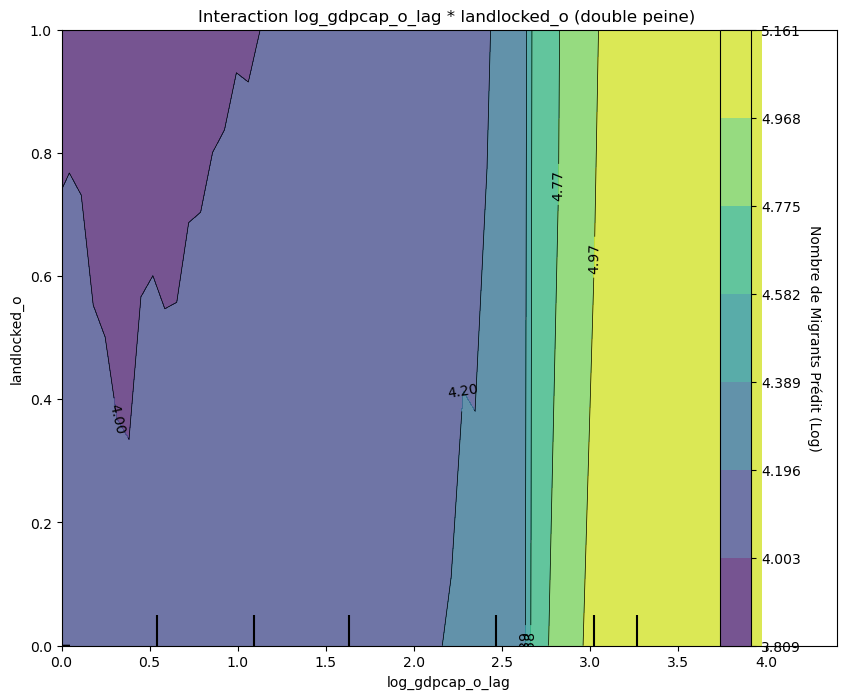

In [122]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# PDP 2D

features_inter = [('log_gdpcap_o_lag', 'landlocked_o')] 
# ------------------

fig, ax = plt.subplots(figsize=(10, 8))

graph= PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    percentiles=(0, 1),   # Gamme complète
    n_cols=1,             
    ax=ax
)
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Nombre de Migrants Prédit (Log)', rotation=270, labelpad=15)
plt.title("Interaction log_gdpcap_o_lag * landlocked_o (double peine) ")
plt.xlim(0,4.4)
plt.show()

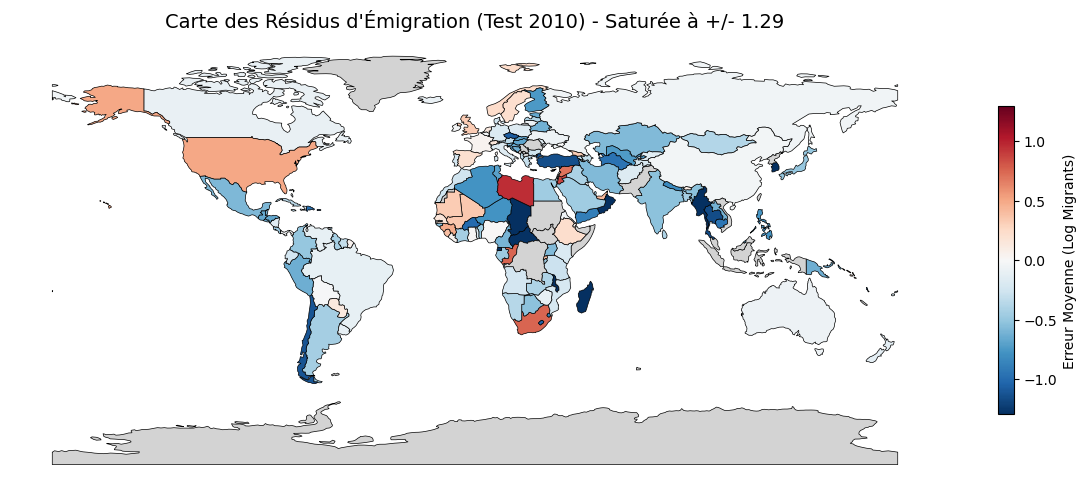

In [123]:
# Carte des Résidus 


# 1) Calcul des résidus
test_df['residuals'] = test_df[target] - rf.predict(X_test)
resid_by_country = test_df.groupby('iso3_o')['residuals'].mean().reset_index()

# 2) Chargement du fond de carte (url directe natural earth)

url_world = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_world)

# 3) Harmonisation des codes ISO (Natural Earth utilise souvent 'ADM0_A3' ou 'ISO_A3')
# On s'assure d'avoir une colonne 'iso_a3' minuscule pour votre fusion
col_iso = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
world['iso_a3'] = world[col_iso]

# 4) Fusion
world_map = world.merge(resid_by_country, left_on='iso_a3', right_on='iso3_o', how='left')

# 5) Vizu
v_max = world_map['residuals'].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(15, 8))
world_map.plot(
    column='residuals', 
    cmap='RdBu_r', 
    linewidth=0.5,
    edgecolor='black',
    ax=ax, 
    legend=True,
    vmin=-v_max, 
    vmax=v_max,
    missing_kwds={'color': 'lightgrey', 'label': 'Pas de données'},
    legend_kwds={'label': "Erreur Moyenne (Log Migrants)", 'shrink': 0.5}
)
ax.set_title(f"Carte des Résidus d'Émigration (Test 2010) - Saturée à +/- {v_max:.2f}", fontsize=14)
ax.axis('off')
plt.show()

Commentaires: 

ATTENTION avec gdpcap à t-5 on se trompe sur les Etats unis (sous estime). (?)


ZONES BLEUES (le modèle sur-estime les flux "réels")



- Niger Tchad Burkina Faso RépCentrafricaine: TRAPPE A PAUVRETé que le modèle a réussi à capter (cf courbe à seuil pour gdpcap_o), mais il en sous estime encore la puissance (il prédit un plus faible nombre de migrants, alors qu'en réalité ce nombre est vraiment proche du néant)

- Arabie Saoudite : le modèle voit un pays riche et connecté à l'international, il prédit une migration comparable aux pays occidentaux. En réalité, le pays est stabilisé par sa "rente pétrolière" qui achète et sédentarise les nationaux. 

- Chili : isolement géographique par les Andes ? stabilité culturelle, nationaux attachés peut être ? 

- Myanmar: dictature qui ferme le pays en 2010. 

- madagascar: combinaison de la trappe à pauvreté avec l'isolement insulaire, les billets d'avions sont infiniment chers pour les locaux.

- Algérie : le modèle capte la proxmité coloniale, mais en réalité l'obtention d'un visa Schenghen refroidit le potentiel de proximité coloniale. Le désir de migrer est là, la possiblité  légale l'est moins.

- Kazakhstan: le modèle a appris sur le départ des soviétiques après la chute de l'URSS en 90-2000, et a anticipté des trop gros flux en 2010 alors que l'économie s'était stabilisée. 



ZONES ROUGES (le modèle sous-estime les flux "réels")



- Libye: problème ici ? khadafi règnait jusqu'en 2011 et fermait le pays. 

- Israel : diaspora, israeliens ont souvent double nationalité, circulent facilement, hyper-mobilité que le modèle n'a pas capté.

- Rép du Congo Brazzaville: plus stable que le Congo Kinshasa, assez pauvre mais avec liens coloniaux français plus forts que le modèle pensait (variable gdpcap * dummy liens coloniaux ? )
Le modèle prédit bien pour Congo belge.

- Afrique du Sud: pays du BRICS très émergent, le modèle prévoit une stabilité et sédentarité. Or la criminalité assez fortement tjr présente pousse les classes moyennes/supérieures à fuir 




In [ ]:
import pandas as pd
from cmdstanpy import CmdStanModel

#liste de variables
features = [
    'log_pop_o', 'log_pop_d', 'log_distcap', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d',
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d',
    'landlocked_o', 'landlocked_d', 
    'contig', 'comlang_off', 'col_dep_ever', 
    't_centered', 't_centered_sq', 
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]

# 1. Préparation des données pour Stan
# Stan ne lit pas les DataFrame, il veut un dictionnaire avec des matrices numpy
stan_data = {
    'N': len(train_df),
    'K': len(features),
    'X': train_df[features].values,            # On passe tout le bloc X d'un coup
    'y': train_df['log_migrantCount'].values   # La cible
}

# 2. Compilation et Sampling

model = CmdStanModel(stan_file='MCMC.stan')

# On lance 4 chaînes en parallèle
fit = model.sample(data=stan_data, chains=4, iter_sampling=1000)

# 3. Résultats
print(fit.summary())

19:50:26 - cmdstanpy - INFO - compiling stan file /var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/tmpkr2smjiy/tmpbkv86xdz.stan to exe file /Users/romain/Desktop/Projets DS/ProjetStat/MCMC
19:50:34 - cmdstanpy - INFO - compiled model executable: /Users/romain/Desktop/Projets DS/ProjetStat/MCMC
19:50:35 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:22:43 - cmdstanpy - INFO - CmdStan done processing.



                  Mean      MCSE    StdDev       MAD            5%  \
lp__     -85130.600000  0.075448  3.281040  3.175730 -85136.600000   
alpha        -3.264720  0.004393  0.206754  0.207384     -3.605520   
beta[1]       0.590999  0.000126  0.006746  0.006742      0.579841   
beta[2]       0.525004  0.000117  0.006602  0.006678      0.514094   
beta[3]      -1.263710  0.000159  0.009962  0.010301     -1.279980   
beta[4]       0.078619  0.000329  0.019151  0.019286      0.047525   
beta[5]      -0.413909  0.000339  0.019548  0.019847     -0.446095   
beta[6]      -0.351508  0.000414  0.021312  0.021456     -0.386318   
beta[7]      -0.137190  0.000447  0.021160  0.020953     -0.172414   
beta[8]      -0.308889  0.000429  0.024374  0.024466     -0.348658   
beta[9]      -0.283650  0.000453  0.025377  0.025629     -0.324117   
beta[10]      0.123064  0.000092  0.005269  0.005317      0.114509   
beta[11]      0.172868  0.000094  0.005148  0.005104      0.164177   
beta[12]     -0.318

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Extraction des 4000 simulations (Posterior)
alpha_samples = fit.stan_variable('alpha')  # shape: (4000,)
beta_samples  = fit.stan_variable('beta')   # shape: (4000, 20)

# 2. Données de Test
X_test = test_df[features].values
y_true_real = np.exp(test_df['log_migrantCount']) # On veut comparer en "vrais" migrants

# 3. Calcul Vectorisé : On prédit pour chaque ligne, selon les 4000 avis du modèle
# Résultat : une matrice (Nombre_pays x 4000)
y_log_pred_samples = alpha_samples + np.dot(X_test, beta_samples.T)

# 4. Aggrégation : On prend la moyenne des prédictions (en log) puis on exponentie
y_pred_mean = np.exp(y_log_pred_samples.mean(axis=1))

# 5. Calcul des erreurs
mse_bayes = mean_squared_error(y_true_real, y_pred_mean)
mape_bayes = mean_absolute_percentage_error(y_true_real, y_pred_mean)

print(f"RÉSULTATS STAN (Test sur 2010 ) ")
print(f"MSE  : {mse_bayes:,.0f}")
print(f"MAPE : {mape_bayes:.2%}")

RÉSULTATS STAN (Test sur 2010 ) 
MSE  : 19,841,685,983
MAPE : 744.63%


Mieux que l'OLS (modèle Stan avec prior beta entre -10 et 10 évite de dire n'importe quoi pour les petits pays contrairement à OLS), moins bon que Random Forest. Welch & Raftery obtiennent MAPE de 76%, grâce à leur modèle hiérarchique. Notre modèle n'est pas hiérarchique
Random FOrest qui capte les seuils notamment les trappes à pauvreté, est bien meilleur que notre modèle STAN, mais toujours moins bon que le modèle bayésien hiéararchique de W&R